In [1]:
import pandas as pd


In [3]:
silver_df = pd.read_csv("data/silver/cleaned_claims.csv")

silver_df.head(20)

,claim_id,customer_id,policy_type,claim_amount,claim_status,incident_type,state,adjuster_id,fraud_flag,claim_date,high_value_claim,high_risk_incident,suspicious_claim,claim_severity
0,1,1858,Auto,21405.32,Denied,Accident,NE,226,0,2026-05-25 10:28:28.319826,False,False,False,High
1,2,1522,Life,26014.20,Denied,Flood,FL,241,0,2026-05-25 10:28:28.319873,False,False,False,High
2,3,3387,Home,10261.01,Pending,Accident,TN,283,0,2026-05-25 10:28:28.319895,False,False,False,Medium
3,4,3155,Auto,48596.16,Pending,Flood,LA,117,0,2026-05-25 10:28:28.319908,True,False,False,Critical
4,5,3496,Life,23920.96,Approved,Flood,MD,292,0,2026-05-25 10:28:28.319923,False,False,False,High
5,6,3248,Life,30712.12,Approved,Accident,VA,172,0,2026-05-25 10:28:28.319936,True,False,False,High
6,7,1290,Life,9925.26,Pending,Fire,OR,162,0,2026-05-25 10:28:28.319948,False,True,False,Medium
7,8,3355,Home,49833.95,Approved,Fire,AR,159,0,2026-05-25 10:28:28.319960,True,True,True,Critical
8,9,4784,Home,2849.13,Pending,Flood,VA,173,0,2026-05-25 10:28:28.319970,False,False,False,Medium
9,10,3256,Life,48582.11,Pending,Accident,MN,175,0,2026-05-25 10:28:28.319983,True,False,False,Critical


In [4]:
gold_df = pd.read_csv("data/gold/claims_kpis.csv")

gold_df

,total_claims,total_claim_amount,average_claim_amount,suspicious_claims,high_value_claims,approved_claims,denied_claims,pending_claims
0,1000,25713185.11,25713.19,416,418,313,349,338


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
claims_df = pd.read_csv("data/silver/cleaned_claims.csv")

policy_df = pd.read_csv(
    "data/gold/policy_risk_scores.csv"
)

adjuster_df = pd.read_csv(
    "data/gold/adjuster_workload_analysis.csv"
)

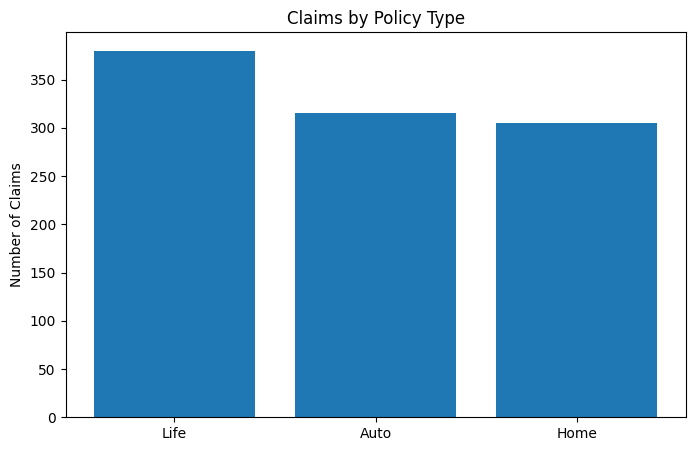

In [7]:
policy_counts = claims_df["policy_type"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    policy_counts.index,
    policy_counts.values
)

plt.title("Claims by Policy Type")
plt.ylabel("Number of Claims")

plt.show()

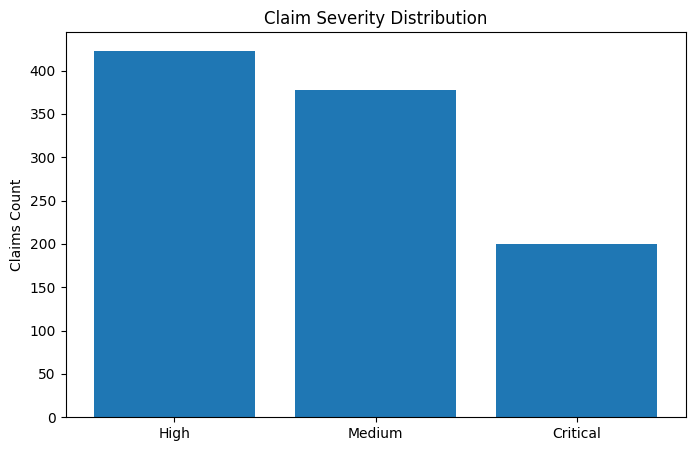

In [8]:
severity_counts = claims_df[
    "claim_severity"
].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    severity_counts.index,
    severity_counts.values
)

plt.title("Claim Severity Distribution")
plt.ylabel("Claims Count")

plt.show()

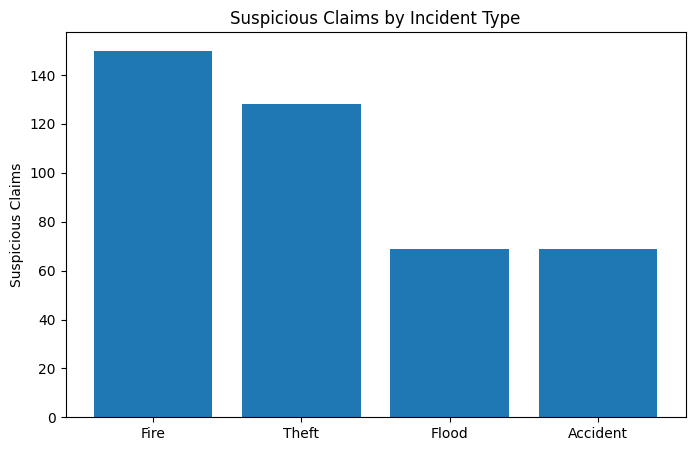

In [9]:
suspicious_df = claims_df[
    claims_df["suspicious_claim"] == True
]

incident_counts = suspicious_df[
    "incident_type"
].value_counts()

plt.figure(figsize=(8,5))

plt.bar(
    incident_counts.index,
    incident_counts.values
)

plt.title("Suspicious Claims by Incident Type")
plt.ylabel("Suspicious Claims")

plt.show()

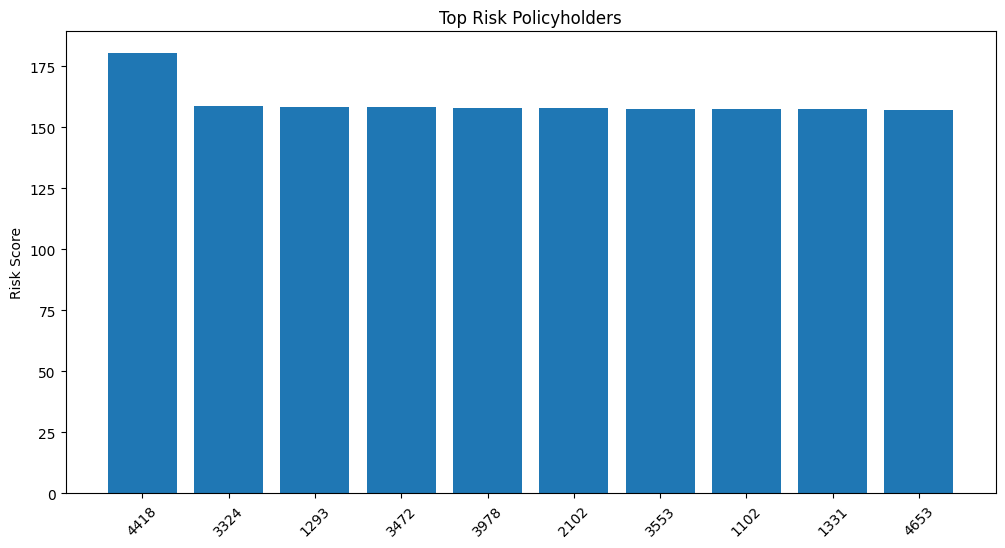

In [10]:
top_risk = policy_df.sort_values(
    by="risk_score",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_risk["customer_id"].astype(str),
    top_risk["risk_score"]
)

plt.title("Top Risk Policyholders")
plt.ylabel("Risk Score")

plt.xticks(rotation=45)

plt.show()

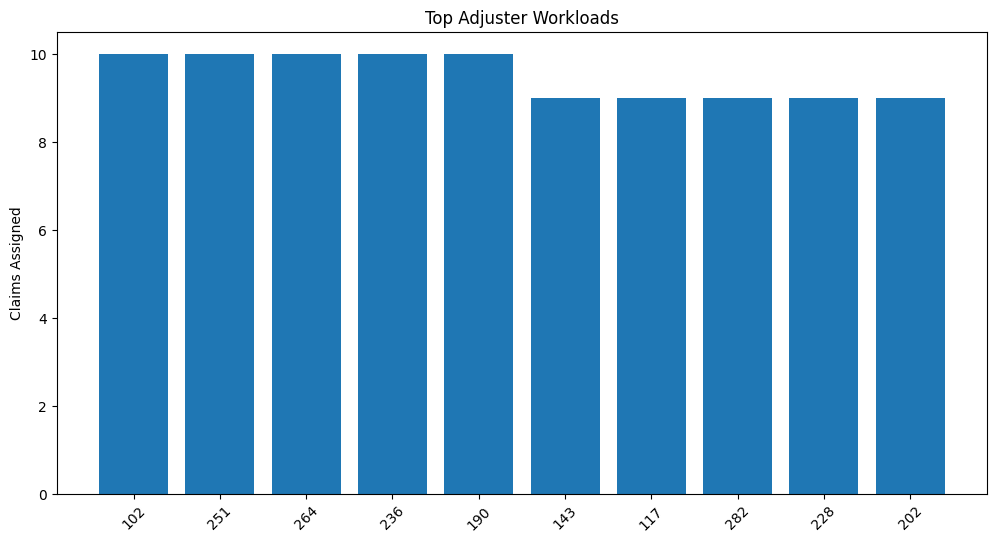

In [11]:
top_adjusters = adjuster_df.sort_values(
    by="total_claims",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_adjusters["adjuster_id"].astype(str),
    top_adjusters["total_claims"]
)

plt.title("Top Adjuster Workloads")
plt.ylabel("Claims Assigned")

plt.xticks(rotation=45)

plt.show()

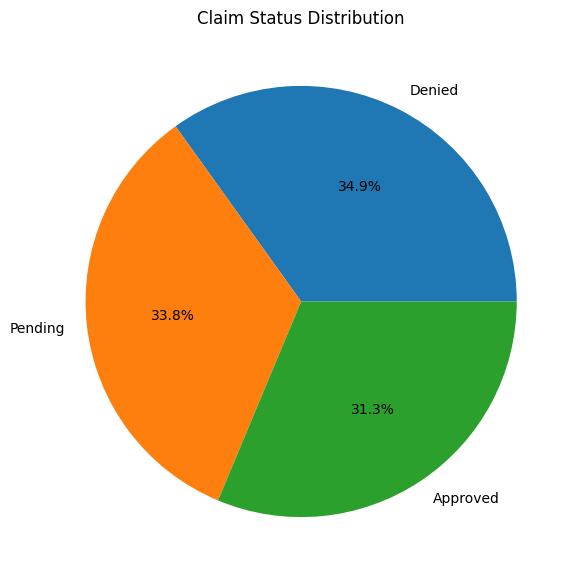

In [12]:
status_counts = claims_df[
    "claim_status"
].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    status_counts.values,
    labels=status_counts.index,
    autopct='%1.1f%%'
)

plt.title("Claim Status Distribution")

plt.show()

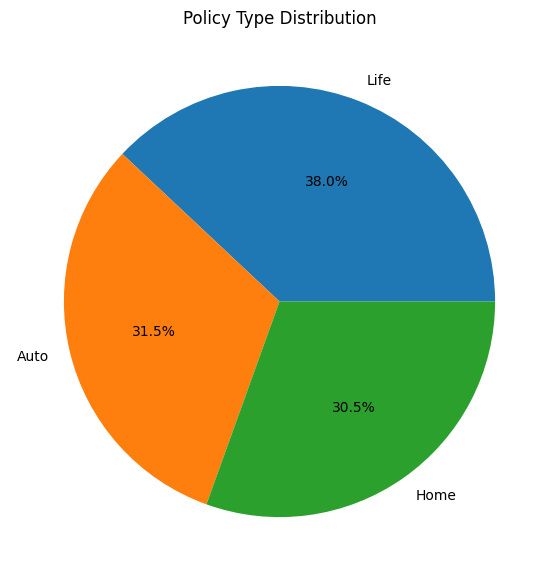

In [13]:
policy_counts = claims_df[
    "policy_type"
].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    policy_counts.values,
    labels=policy_counts.index,
    autopct='%1.1f%%'
)

plt.title("Policy Type Distribution")

plt.show()

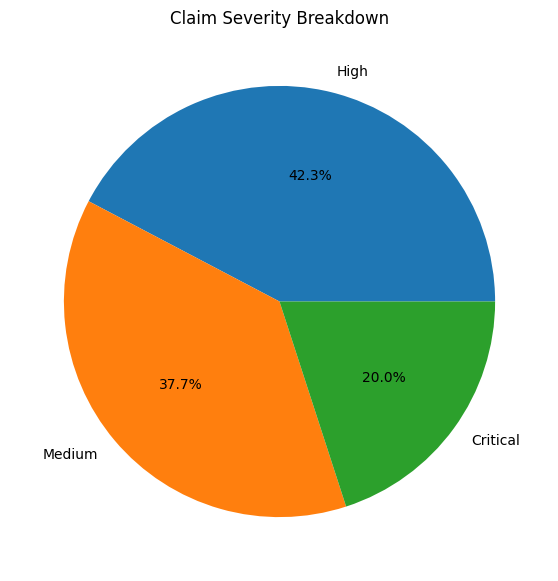

In [14]:
severity_counts = claims_df[
    "claim_severity"
].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    severity_counts.values,
    labels=severity_counts.index,
    autopct='%1.1f%%'
)

plt.title("Claim Severity Breakdown")

plt.show()

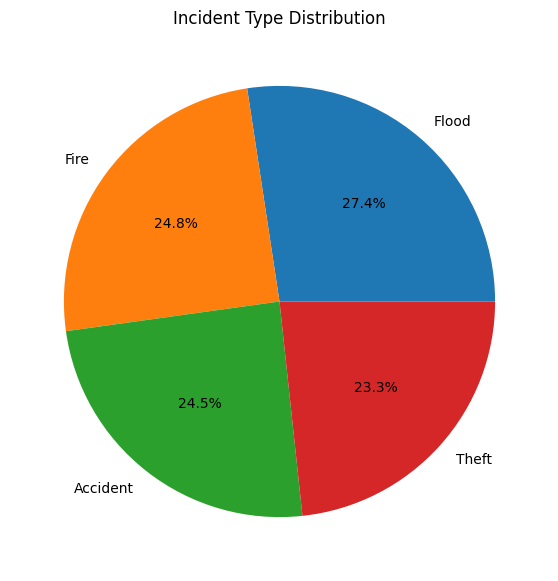

In [15]:
incident_counts = claims_df[
    "incident_type"
].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    incident_counts.values,
    labels=incident_counts.index,
    autopct='%1.1f%%'
)

plt.title("Incident Type Distribution")

plt.show()

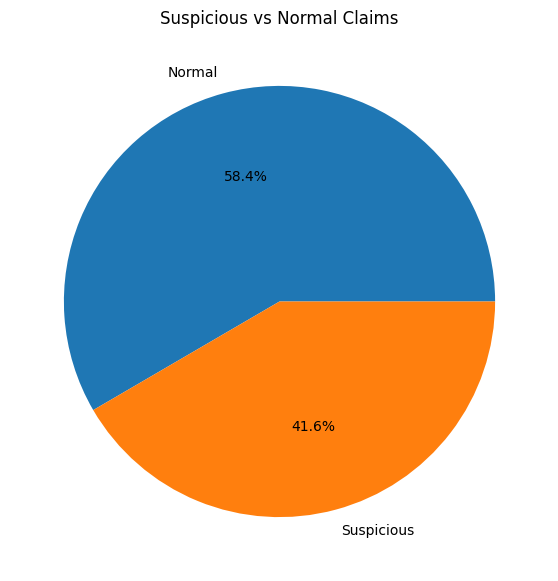

In [16]:
fraud_counts = claims_df[
    "suspicious_claim"
].replace(
    {
        True: "Suspicious",
        False: "Normal"
    }
).value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    fraud_counts.values,
    labels=fraud_counts.index,
    autopct='%1.1f%%'
)

plt.title("Suspicious vs Normal Claims")

plt.show()